In [33]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os
import pandas as pd

In [ ]:
# Download Natural Earth dataset for countries (1:110m scale)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
gdf = gpd.read_file(url)

maps_dir = "../maps"
os.makedirs(maps_dir, exist_ok=True)
gdf.to_file(os.path.join(maps_dir, "ne_110m_admin_0_countries.gpkg"), driver="GPKG")

In [35]:
gdf = gpd.read_file(os.path.join(maps_dir, "ne_110m_admin_0_countries.gpkg"))

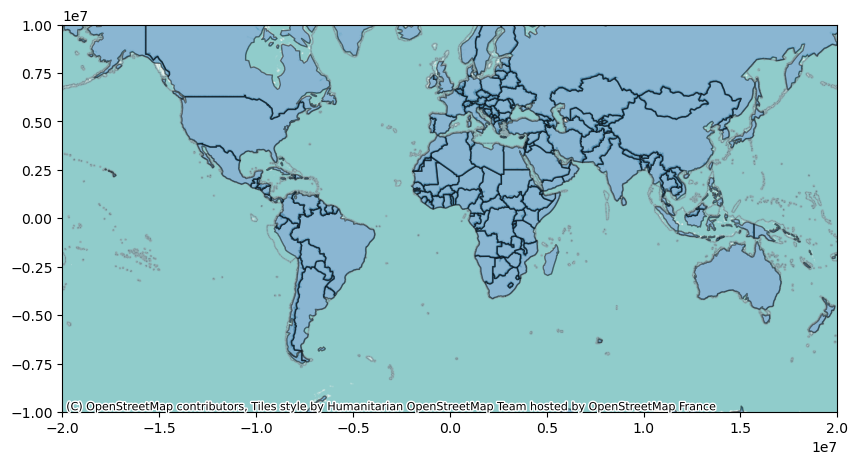

In [36]:
# Convert geometries to Web Mercator (EPSG:3857) for basemap compatibility
gdf = gdf.to_crs(epsg=3857)
# Plotting the country boundaries
ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')
# Setting the xlim and ylim to zoom into the world map
ax.set_xlim([-2e7, 2e7])
ax.set_ylim([-1e7, 1e7])
# Adding a basemap for context
ctx.add_basemap(ax)
plt.show()

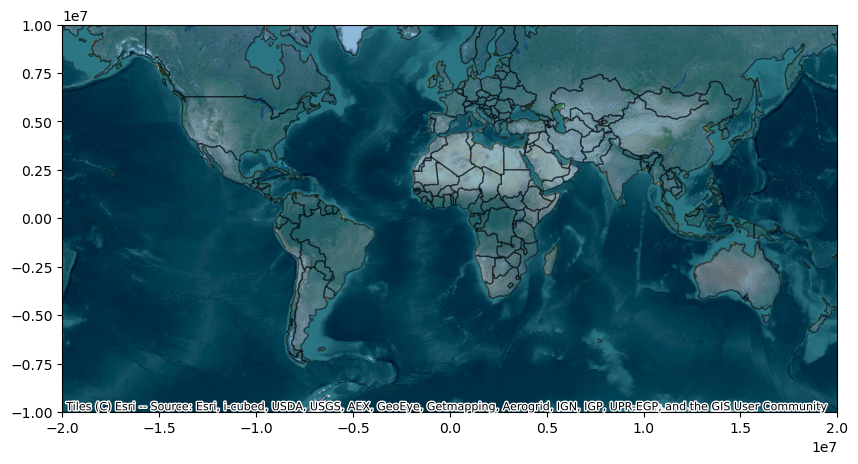

In [37]:
gdf = gdf.to_crs(epsg=3857)

# Plotting the country boundaries
ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

# Setting the xlim and ylim to zoom into the world map
ax.set_xlim([-2e7, 2e7])
ax.set_ylim([-1e7, 1e7])
# Adding a basemap for a satellite image
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
plt.show()

In [5]:
print(ctx.providers.keys())  # Lists available tile providers

dict_keys(['OpenStreetMap', 'MapTilesAPI', 'OpenSeaMap', 'OPNVKarte', 'OpenTopoMap', 'OpenRailwayMap', 'OpenFireMap', 'SafeCast', 'Stadia', 'Thunderforest', 'CyclOSM', 'Jawg', 'MapBox', 'MapTiler', 'Stamen', 'TomTom', 'Esri', 'OpenWeatherMap', 'HERE', 'HEREv3', 'FreeMapSK', 'MtbMap', 'CartoDB', 'HikeBike', 'BasemapAT', 'nlmaps', 'NASAGIBS', 'NLS', 'JusticeMap', 'GeoportailFrance', 'OneMapSG', 'USGS', 'WaymarkedTrails', 'OpenAIP', 'OpenSnowMap', 'AzureMaps', 'SwissFederalGeoportal', 'Gaode', 'Strava'])


In [6]:
print(ctx.providers.Esri.keys())  # Lists all maps under the Esri provider
print(ctx.providers.Stamen.keys())  
print(ctx.providers.Strava.keys())  

dict_keys(['WorldStreetMap', 'DeLorme', 'WorldTopoMap', 'WorldImagery', 'WorldTerrain', 'WorldShadedRelief', 'WorldPhysical', 'OceanBasemap', 'NatGeoWorldMap', 'WorldGrayCanvas', 'ArcticImagery', 'ArcticOceanBase', 'ArcticOceanReference', 'AntarcticImagery', 'AntarcticBasemap'])
dict_keys(['Toner', 'TonerBackground', 'TonerHybrid', 'TonerLines', 'TonerLabels', 'TonerLite', 'Watercolor', 'Terrain', 'TerrainBackground', 'TerrainLabels', 'TopOSMRelief', 'TopOSMFeatures'])
dict_keys(['All', 'Ride', 'Run', 'Water', 'Winter'])


In [ ]:
sample_locations = pd.read_pickle("../pkl/sample_observations_20260130.pkl")
# display(sample_locations.style.hide(axis="index").format(precision=2))

gdf = gdf.to_crs(epsg=3857)
# Plotting the country boundaries
ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')
# Zoom into a specific region
ax.set_xlim([-2200000, 700000])  
ax.set_ylim([2860000, 5600000]) 
# Adding a basemap for a street map image
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)
plt.show()

idema,fint,ubi,lon,lat,prec,ta,dmax,hr
1050J,2026-01-30T10h,ELGOIBAR,-2.41,43.21,nan,13.70,168.00,54.00
1302F,2026-01-30T14h,DEGAÑA COTO CORTÉS,-6.47,42.96,3.40,2.60,317.00,91.00
9069C,2026-01-30T04h,MIRANDA DE EBRO,-2.96,42.69,0.00,7.10,300.00,74.00
9590,2026-01-30T14h,MARTINET,1.69,42.36,0.00,nan,272.00,nan
9495Y,2026-01-30T14h,LECIÑENA,-0.62,41.80,0.00,12.00,240.00,61.00
0222X,2026-01-30T05h,CALDES DE MONTBUI,2.17,41.61,0.00,9.70,280.00,68.00
3343Y,2026-01-30T07h,VALDEMORILLO,-4.06,40.50,0.00,3.80,227.00,95.00
8050X,2026-01-30T16h,JÁVEA AYUNTAMIENTO,0.17,38.78,0.00,17.00,192.00,48.00
6291B,2026-01-30T12h,EL EJIDO (AYUNTAMIENTO - AUTOMATICA),-2.81,36.77,0.00,21.90,nan,42.00
C449C,2026-01-30T05h,SANTA CRUZ DE TENERIFE,-16.26,28.46,0.00,17.20,293.00,77.00


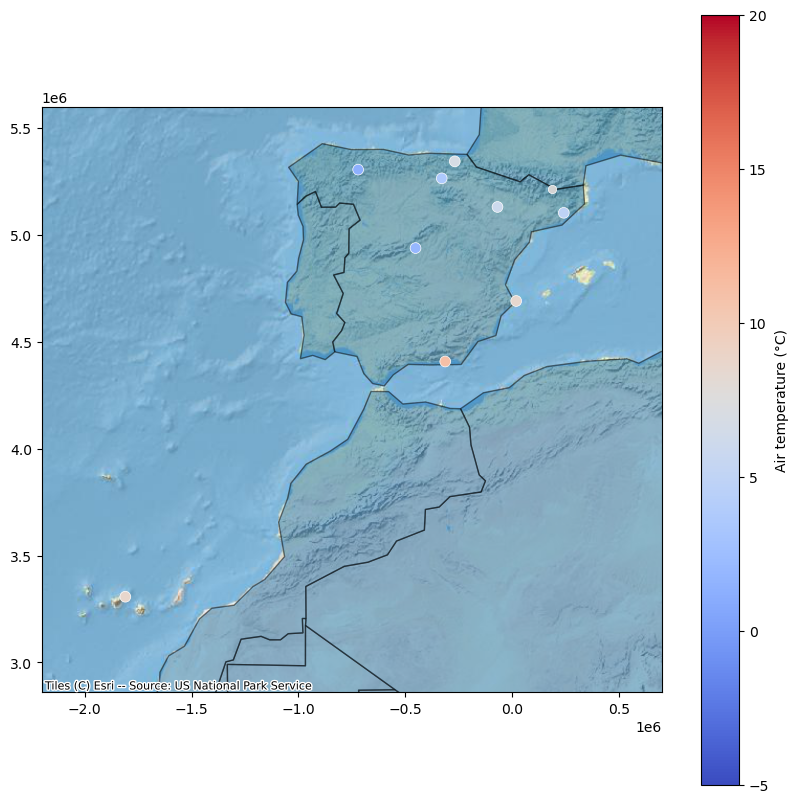

In [31]:
display(sample_locations.style.hide(axis="index").format(precision=2))

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='ta',
    cmap='coolwarm',
    vmin=-10,
    vmax=40,
    markersize=60,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-2200000, 700000])
ax.set_ylim([2860000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=-5, vmax=20), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Air temperature (°C)")

plt.show()